##### **How can different NLP techniques represent and analyze movie-review text?**

In [22]:
import pandas as pd

In [14]:
reviews = [
    "I loved the movie. It was amazing!",
    "The movie was okay.",
    "I hated the movie. It was boring.",
    "The acting was brilliant and impressive.",
    "The story was confusing and poorly written.",
    "What a fantastic film. I really enjoyed it."
]

Data Preprocessing

In [3]:
import nltk

In [ ]:
nltk.download("punkt_tab")

import string
punctuations = string.punctuation

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Senthil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Senthil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def preprocess(review):
    review = review.lower()
    tokens = nltk.word_tokenize(review)
    # remove punctuations
    tokens = [token for token in tokens if token not in punctuations]
    # lemmatize
    return " ".join(tokens)

In [15]:
reviews = [preprocess(review) for review in reviews]

In [16]:
reviews

['i loved the movie it was amazing',
 'the movie was okay',
 'i hated the movie it was boring',
 'the acting was brilliant and impressive',
 'the story was confusing and poorly written',
 'what a fantastic film i really enjoyed it']

Bag of words using `CountVectorizer`

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()
X_cv = count_vectorizer.fit_transform(reviews)

In [18]:
count_vectorizer.get_feature_names_out()

array(['acting', 'amazing', 'and', 'boring', 'brilliant', 'confusing',
       'enjoyed', 'fantastic', 'film', 'hated', 'impressive', 'it',
       'loved', 'movie', 'okay', 'poorly', 'really', 'story', 'the',
       'was', 'what', 'written'], dtype=object)

In [49]:
pd.DataFrame(data=X_cv.toarray(), columns=count_vectorizer.get_feature_names_out())

,acting,amazing,and,boring,brilliant,confusing,enjoyed,fantastic,film,hated,...,loved,movie,okay,poorly,really,story,the,was,what,written
0,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,1,1,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,1,0,0
2,0,0,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,1,1,0,0
3,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
4,0,0,1,0,0,1,0,0,0,0,...,0,0,0,1,0,1,1,1,0,1
5,0,0,0,0,0,0,1,1,1,0,...,0,0,0,0,1,0,0,0,1,0


Which words appear most often across all our reviews?

In [27]:
import numpy as np
import matplotlib.pyplot as plt

<BarContainer object of 22 artists>

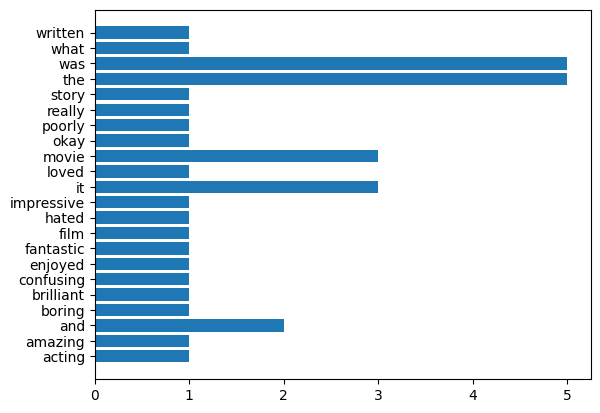

In [29]:

plt.barh(count_vectorizer.get_feature_names_out(),  np.sum(X_cv.toarray(), axis=0))

How important is this word in this particular review using `TfIdfVectorizer`

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

In [31]:
X_tfidf = tfidf_vectorizer.fit_transform(reviews)

In [32]:
X_tfidf.toarray()

array([[0.        , 0.53578303, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.37092925, 0.53578303, 0.37092925, 0.        ,
        0.        , 0.        , 0.        , 0.27449597, 0.27449597,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.48901903, 0.706356  ,
        0.        , 0.        , 0.        , 0.36188506, 0.36188506,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.53578303, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.53578303,
        0.        , 0.37092925, 0.        , 0.37092925, 0.        ,
        0.        , 0.        , 0.        , 0.27449597, 0.27449597,
        0.        , 0.        ],
       [0.48810225, 0.        , 0.40025083, 0.        , 0.48810225,
        0.       

In [33]:
tfidf_vectorizer.get_feature_names_out()

array(['acting', 'amazing', 'and', 'boring', 'brilliant', 'confusing',
       'enjoyed', 'fantastic', 'film', 'hated', 'impressive', 'it',
       'loved', 'movie', 'okay', 'poorly', 'really', 'story', 'the',
       'was', 'what', 'written'], dtype=object)

In [68]:
tfidf_df = pd.DataFrame(data=X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

capture relationships/meaning between words `Embeddings`

In [35]:
import gensim.downloader as api

model = api.load('glove-wiki-gigaword-50')

In [36]:
movie_vector = model["movie"]

print(movie_vector)

[ 0.30824   0.17223  -0.23339   0.023105  0.28522   0.23076  -0.41048
 -1.0035   -0.2072    1.4327   -0.80684   0.68954  -0.43648   1.1069
  1.6107   -0.31966   0.47744   0.79395  -0.84374   0.064509  0.90251
  0.78609   0.29699   0.76057   0.433    -1.5032   -1.6423    0.30256
  0.30771  -0.87057   2.4782   -0.025852  0.5013   -0.38593  -0.15633
  0.45522   0.04901  -0.42599  -0.86402  -1.3076   -0.29576   1.209
 -0.3127   -0.72462  -0.80801   0.082667  0.26738  -0.98177  -0.32147
  0.99823 ]


In [37]:
similarity = model.similarity("movie", "film")

print(similarity)

0.93100995


In [38]:
similar_words = model.most_similar("movie", topn=5)

print(similar_words)

[('movies', 0.9322481155395508), ('film', 0.9310100078582764), ('films', 0.8937394618988037), ('comedy', 0.8902585506439209), ('hollywood', 0.8718216419219971)]


In [39]:
words = ["movie", "film", "actor", "story", "performance", "dog"]

In [40]:
word_vectors = [model[word] for word in words]

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

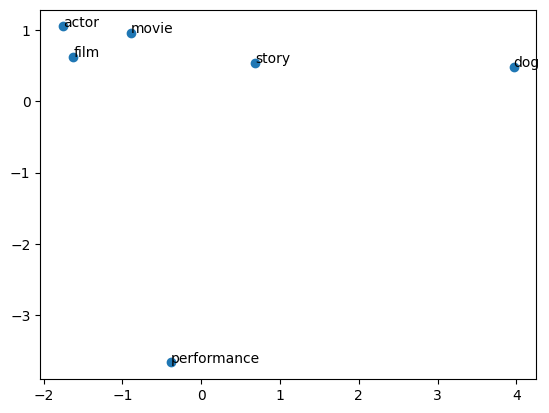

In [47]:
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1])
for word, (x, y) in zip(words, word_vectors_2d): 
    plt.annotate(word, (x, y)) 
plt.show()

**Comparison**

In [59]:
words = count_vectorizer.get_feature_names_out()
word_count = X_cv.toarray().sum(axis=0)

In [65]:
bow_df = pd.DataFrame({
    "word" : words,
    "word count" : word_count
})

In [66]:
bow_df

,word,word count
0,acting,1
1,amazing,1
2,and,2
3,boring,1
4,brilliant,1
5,confusing,1
6,enjoyed,1
7,fantastic,1
8,film,1
9,hated,1


In [69]:
tfidf_df

,acting,amazing,and,boring,brilliant,confusing,enjoyed,fantastic,film,hated,...,loved,movie,okay,poorly,really,story,the,was,what,written
0,0.000000,0.535783,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.535783,0.370929,0.000000,0.000000,0.000000,0.000000,0.274496,0.274496,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.489019,0.706356,0.000000,0.000000,0.000000,0.361885,0.361885,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.535783,0.000000,0.000000,0.000000,0.000000,0.000000,0.535783,...,0.000000,0.370929,0.000000,0.000000,0.000000,0.000000,0.274496,0.274496,0.000000,0.000000
3,0.488102,0.000000,0.400251,0.000000,0.488102,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250068,0.250068,0.000000,0.000000
4,0.000000,0.000000,0.359691,0.000000,0.000000,0.438639,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.438639,0.000000,0.438639,0.224727,0.224727,0.000000,0.438639
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.427206,0.427206,0.427206,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.427206,0.000000,0.000000,0.000000,0.427206,0.000000


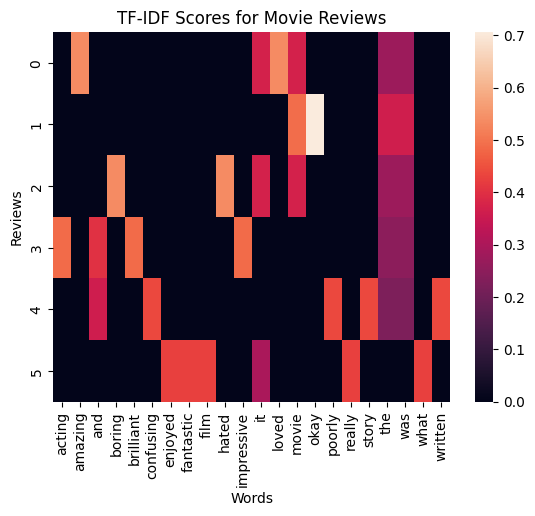

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(tfidf_df)

plt.title("TF-IDF Scores for Movie Reviews")
plt.xlabel("Words")
plt.ylabel("Reviews")
plt.show()

Conclusion:
1. In this project, movie reviews were represented using three NLP techniques: Bag-of-Words, TF-IDF, and word embeddings. 
2. BoW captured word frequency, TF-IDF captured the relative importance of words within the reviews, and word embeddings allowed us to explore semantic relationships between words. 
3. PCA was then used to visualize the high-dimensional word embeddings in two dimensions.